In [42]:
# -------------------- LangGraph --------------------
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.sqlite import SqliteSaver


# -------------------- Python --------------------
import os
import sqlite3
import tempfile
from typing import Annotated, Any, Dict, Optional, TypedDict


# -------------------- Environment --------------------
from dotenv import load_dotenv


# -------------------- LangChain Core --------------------
from langchain_core.messages import BaseMessage, SystemMessage,HumanMessage, AIMessage
from langchain_core.tools import tool


# -------------------- LangChain --------------------
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_community.vectorstores import FAISS


# -------------------- LLM + Embeddings --------------------
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings


# -------------------- Other --------------------
import requests

from langgraph.checkpoint.memory import InMemorySaver

from langgraph.types import interrupt, Command

In [43]:
load_dotenv()

True

In [44]:
llm = ChatGroq(model='llama-3.3-70b-versatile')

In [45]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [46]:
def chat_node(state: ChatState):
    messages = state['messages']
    response = llm.invoke(messages)
    
    return {'messages':[response]}

In [47]:
def approval_node(state: ChatState):
    decision = interrupt({
        'type': 'approval',
        'reason': 'Model is about to answer a user question',
        'question':state['messages'][-1].content,
        'Instruction':'Approved this question? yse/no'
    })
    
    if decision['approved'] == 'no':
        return {'messages':[AIMessage(content='Not approved')]}
    else:
        response = llm.invoke(state['messages'])
        return {'messages':[response]}

In [48]:
graph = StateGraph(ChatState)

graph.add_node('chat',chat_node)
graph.add_node('approval_node',approval_node)

graph.add_edge(START, 'chat')
graph.add_edge('chat','approval_node')
graph.add_edge('approval_node',END)

checkpointer = InMemorySaver()

chatbot = graph.compile(checkpointer=checkpointer)

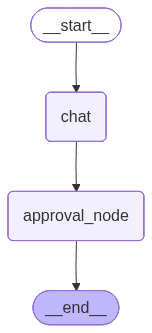

In [49]:
chatbot

In [50]:
config = {'configurable':{'thread_id':'1234'}}

In [51]:
initial_state = {'messages':[HumanMessage(content='Explain linear regression in simple words?')]}
result = chatbot.invoke(initial_state,config=config)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [52]:
result

{'messages': [HumanMessage(content='Explain linear regression in simple words?', additional_kwargs={}, response_metadata={}, id='bc903fa6-a70d-4e9e-8825-04454709c84a'),
  AIMessage(content='**Linear Regression in Simple Words:**\n\nLinear regression is a statistical method that helps us understand the relationship between two things. Let\'s break it down:\n\n* **Goal:** To create a line that best predicts the value of one thing (called the "dependent variable") based on the value of another thing (called the "independent variable").\n* **How it works:**\n\t1. We collect data on both variables.\n\t2. We use a mathematical formula to create a line that minimizes the distance between the actual data points and the predicted line.\n\t3. The resulting line is called the "regression line" or "best fit line".\n* **Example:** Suppose we want to predict how much ice cream people will buy based on the temperature outside. We collect data on temperature and ice cream sales. The linear regression 

In [53]:
user_input = input({'messages'})

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [54]:
final_result = chatbot.invoke(Command(resume={'approved':user_input}), config=config)

In [ ]:
final_result['messages'][-1]

AIMessage(content='', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 1, 'prompt_tokens': 369, 'total_tokens': 370, 'completion_time': 0.006395795, 'completion_tokens_details': None, 'prompt_time': 0.019214086, 'prompt_tokens_details': None, 'queue_time': None, 'total_time': 0.025609881}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ba38bbab80', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f131e-b87e-7063-bd7f-aafa6fb3692e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 369, 'output_tokens': 1, 'total_tokens': 370})

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
